# Generate, Relabel, and Export EIS Data

This notebook generates random EIS curves for `R1-[P2,R3]-[P4,R5]`, filters suspicious high-frequency endpoints, greedily selects 100 diverse curves, relabels them with structural simplification plus FIM redundancy analysis, and exports plots and metadata for sharing.

## two-RC optimization, PCA diagnostics, and UMAP

Optional exploratory diagnostics for the earlier two-RC workflow. Collapse this section if you only need the main random ECM relabel/export workflow.


**Define Two-RC Search Helpers**

Define simulation, normalization, filtering, greedy selection, and PCA plotting helpers for the `R0-p(CPE1,R1)-p(CPE2,R2)` workflow.

In [ ]:
# Diverse-curve search for the ECM: R0-p(CPE1,R1)-p(CPE2,R2)

import os
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
from impedance.models.circuits import CustomCircuit
from tqdm import tqdm

warnings.filterwarnings(
    "ignore", category=UserWarning, message="Simulating circuit based on initial parameters"
)

try:
    frequencies
except NameError:
    frequencies = None

if frequencies is None:
    frequencies = np.logspace(5, -2, 80)

circuit = 'R0-p(CPE1,R1)-p(CPE2,R2)'

def simulate_ecm(params, frequencies=frequencies):
    initial_guess = [float(value) for value in params]
    try:
        model = CustomCircuit(circuit=circuit, initial_guess=initial_guess)
        return model.predict(frequencies)
    except Exception:
        return None

def normalize_curve(Z):
    real = Z.real
    imag = Z.imag
    real_min, real_max = real.min(), real.max()
    imag_min, imag_max = imag.min(), imag.max()

    if real_max > real_min:
        real_norm = (real - real_min) / (real_max - real_min)
    else:
        real_norm = np.zeros_like(real)

    if imag_max > imag_min:
        imag_norm = (imag - imag_min) / (imag_max - imag_min)
    else:
        imag_norm = np.zeros_like(imag)

    return real_norm, imag_norm

def stack_curves(curves):
    if not curves:
        return np.empty((0, 0, 2), dtype=np.float32)

    n_freq = len(curves[0][0])
    curve_points = np.empty((len(curves), n_freq, 2), dtype=np.float32)
    for idx, (re_norm, im_norm) in enumerate(curves):
        if len(re_norm) != n_freq or len(im_norm) != n_freq:
            raise ValueError('All curves must use the same frequency grid')
        curve_points[idx, :, 0] = re_norm
        curve_points[idx, :, 1] = im_norm

    return curve_points


def distances_to_curve(curve_points, reference_curve):
    diff = curve_points - reference_curve[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2)).mean(axis=1)


def curve_distance(curve_a, curve_b):
    points_a = np.vstack(curve_a).T
    points_b = np.vstack(curve_b).T
    return np.mean(np.linalg.norm(points_a - points_b, axis=1))

def sample_candidates(n_candidates=400, seed=42):
    rng = np.random.default_rng(seed)
    candidates = []

    r0_bounds = (1e0, 1e5)
    r_bounds = (1e0, 1e6)
    cpe_bounds = (1e-8, 1e-3)
    alpha_bounds = (0.5, 1.0)

    for _ in range(n_candidates):
        r0 = 10 ** rng.uniform(np.log10(r0_bounds[0]), np.log10(r0_bounds[1]))
        r1 = 10 ** rng.uniform(np.log10(r_bounds[0]), np.log10(r_bounds[1]))
        r2 = 10 ** rng.uniform(np.log10(r_bounds[0]), np.log10(r_bounds[1]))

        cpe1 = 10 ** rng.uniform(np.log10(cpe_bounds[0]), np.log10(cpe_bounds[1]))
        cpe2 = 10 ** rng.uniform(np.log10(cpe_bounds[0]), np.log10(cpe_bounds[1]))

        alpha1 = rng.uniform(alpha_bounds[0], alpha_bounds[1])
        alpha2 = rng.uniform(alpha_bounds[0], alpha_bounds[1])

        candidates.append([r0, cpe1, alpha1, r1, cpe2, alpha2, r2])

    return candidates

def evaluate_candidates(candidates):
    param_list = []
    curves = []

    for params in tqdm(candidates, desc='Simulating candidates'):
        Z = simulate_ecm(params)
        if Z is None:
            continue
        curves.append(normalize_curve(Z))
        param_list.append(params)

    return param_list, curves


def high_frequency_minus_im_norm(curve, high_frequency_index=0):
    return float(curve[1][high_frequency_index])


def filter_high_frequency_curves(
    param_list,
    curves,
    max_high_frequency_minus_im_norm=0.1,
    high_frequency_index=0,
):
    high_frequency_values = np.asarray([
        high_frequency_minus_im_norm(curve, high_frequency_index=high_frequency_index)
        for curve in curves
    ])
    keep_mask = high_frequency_values <= max_high_frequency_minus_im_norm
    kept_idx = np.flatnonzero(keep_mask)
    removed_idx = np.flatnonzero(~keep_mask)

    filtered_params = [param_list[i] for i in kept_idx]
    filtered_curves = [curves[i] for i in kept_idx]

    filter_info = {
        'max_high_frequency_minus_im_norm': max_high_frequency_minus_im_norm,
        'high_frequency_index': high_frequency_index,
        'raw_valid_candidate_count': len(param_list),
        'filtered_candidate_count': len(filtered_params),
        'removed_candidate_count': len(removed_idx),
        'kept_original_idx': kept_idx.tolist(),
        'removed_original_idx': removed_idx.tolist(),
        'high_frequency_minus_im_norm': high_frequency_values.tolist(),
    }

    if not filtered_params:
        raise ValueError(
            'High-frequency filter removed every candidate. '
            'Raise max_high_frequency_minus_im_norm or broaden the candidate sampling range.'
        )

    return filtered_params, filtered_curves, filter_info

def choose_initial_curve(curve_points, start='farthest_from_center'):
    if isinstance(start, (int, np.integer)):
        if start < 0 or start >= len(curve_points):
            raise IndexError('start index is outside the candidate range')
        return int(start)

    if start == 'farthest_from_center':
        center_curve = curve_points.mean(axis=0)
        return int(np.argmax(distances_to_curve(curve_points, center_curve)))

    if start == 'random':
        return int(np.random.default_rng(0).integers(len(curve_points)))

    raise ValueError("start must be an index, 'farthest_from_center', or 'random'")


def greedy_select(
    param_list,
    curves,
    k=30,
    start='farthest_from_center',
    min_distance=None,
    return_scores=False,
):
    if not param_list or k <= 0:
        if return_scores:
            return [], [], []
        return [], []

    curve_points = stack_curves(curves)
    n_select = min(k, len(param_list))

    first_idx = choose_initial_curve(curve_points, start=start)
    selected_idx = [first_idx]
    selection_scores = [np.inf]

    min_dist_to_selected = distances_to_curve(curve_points, curve_points[first_idx])
    min_dist_to_selected[first_idx] = -np.inf

    while len(selected_idx) < n_select:
        best_idx = int(np.argmax(min_dist_to_selected))
        best_score = float(min_dist_to_selected[best_idx])

        if min_distance is not None and best_score < min_distance:
            break

        selected_idx.append(best_idx)
        selection_scores.append(best_score)

        new_dist = distances_to_curve(curve_points, curve_points[best_idx])
        min_dist_to_selected = np.minimum(min_dist_to_selected, new_dist)
        min_dist_to_selected[selected_idx] = -np.inf

    selected_params = [param_list[i] for i in selected_idx]
    if return_scores:
        return selected_params, selected_idx, selection_scores
    return selected_params, selected_idx

def plot_selected(curves, selected_idx):
    plt.figure(figsize=(8, 6))
    for idx, (re_norm, im_norm) in enumerate(curves):
        if idx in selected_idx:
            plt.plot(re_norm, im_norm, linewidth=2.5, alpha=0.95)
        # else:
        #     plt.plot(re_norm, im_norm, linewidth=0.8, color='gray', alpha=0.25)

    plt.xlabel('Normalized Re(Z)')
    plt.ylabel('Normalized Im(Z)')
    plt.title('Normalized Nyquist curves: diverse parameter sets')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def transform_parameters_for_pca(param_list):
    params = np.asarray(param_list, dtype=float)
    feature_names = np.array([
        'log10(R0)', 'log10(CPE1)', 'alpha1',
        'log10(R1)', 'log10(CPE2)', 'alpha2', 'log10(R2)',
    ])
    log_columns = [0, 1, 3, 4, 6]

    transformed = params.copy()
    transformed[:, log_columns] = np.log10(transformed[:, log_columns])
    return transformed, feature_names


def plot_parameter_pca_2d(param_list, selected_idx):
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    if len(param_list) < 2:
        print('Skipping PCA plot: need at least two parameter sets')
        return None

    X, feature_names = transform_parameters_for_pca(param_list)
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_scaled)

    selected_idx = np.asarray(selected_idx, dtype=int)
    explained = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        scores[:, 0], scores[:, 1],
        s=24, color='0.78', alpha=0.55, label='All valid candidates',
    )
    plt.scatter(
        scores[selected_idx, 0], scores[selected_idx, 1],
        s=44, color='tab:red', edgecolor='black', linewidth=0.35,
        alpha=0.9, label='Selected curves',
    )

    pc1_top = feature_names[np.argsort(np.abs(pca.components_[0]))[::-1][:3]]
    pc2_top = feature_names[np.argsort(np.abs(pca.components_[1]))[::-1][:3]]
    loading_text = (
        'PC1 top loadings: ' + ', '.join(pc1_top) + '\n'
        'PC2 top loadings: ' + ', '.join(pc2_top)
    )
    plt.gca().text(
        0.02, 0.98, loading_text,
        transform=plt.gca().transAxes,
        va='top', ha='left', fontsize=9,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.85', 'alpha': 0.9},
    )

    plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
    plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
    plt.title('2D PCA of element parameters')
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False, loc='best')
    plt.tight_layout()
    plt.show()

    return {
        'scores': scores,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'components': pca.components_,
        'feature_names': feature_names.tolist(),
    }


def plot_curve_pca_2d(curves, selected_idx):
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    if len(curves) < 2:
        print('Skipping curve PCA plot: need at least two curves')
        return None

    curve_points = stack_curves(curves)
    X = curve_points.reshape(len(curves), -1)
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(X_scaled)

    selected_idx = np.asarray(selected_idx, dtype=int)
    explained = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        scores[:, 0], scores[:, 1],
        s=24, color='0.78', alpha=0.55, label='All valid candidates',
    )
    plt.scatter(
        scores[selected_idx, 0], scores[selected_idx, 1],
        s=44, color='tab:red', edgecolor='black', linewidth=0.35,
        alpha=0.9, label='Selected curves',
    )

    plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
    plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
    plt.title('2D PCA of normalized Nyquist curves')
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False, loc='best')
    plt.tight_layout()
    plt.show()

    return {
        'scores': scores,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'components': pca.components_,
    }

**Run Two-RC Selection**

Sample two-RC candidates, filter high-frequency endpoints, select diverse curves, plot diagnostics, and save selected parameter metadata.

In [ ]:
# Run the search
candidates = sample_candidates(n_candidates=1000, seed=42)
raw_param_list, raw_curves = evaluate_candidates(candidates)

# Keep only curves whose high-frequency endpoint is near the bottom of the
# normalized Nyquist plot. Since the plotted y-value is -im_norm, this removes
# curves whose high-frequency endpoint starts above -0.8.
high_frequency_index = 0
max_high_frequency_minus_im_norm = 0.1
param_list, curves, high_frequency_filter_info = filter_high_frequency_curves(
    raw_param_list,
    raw_curves,
    max_high_frequency_minus_im_norm=max_high_frequency_minus_im_norm,
    high_frequency_index=high_frequency_index,
)

max_selected_curves = 100
# Set this to a positive value, for example 0.02, to stop once each new curve
# adds less than that much normalized curve-distance coverage.
distance_threshold = None

selected_params, selected_idx, selection_scores = greedy_select(
    param_list,
    curves,
    k=max_selected_curves,
    start='farthest_from_center',
    min_distance=distance_threshold,
    return_scores=True,
)

plot_selected(curves, selected_idx)
parameter_pca_result = plot_parameter_pca_2d(param_list, selected_idx)
curve_pca_result = plot_curve_pca_2d(curves, selected_idx)

print(
    f"High-frequency filter kept {high_frequency_filter_info['filtered_candidate_count']} "
    f"of {high_frequency_filter_info['raw_valid_candidate_count']} valid candidates "
    f"(normalized -Im(Z)[{high_frequency_index}] <= {max_high_frequency_minus_im_norm})"
)
print(f'Selected {len(selected_idx)} curves out of {len(param_list)} filtered candidates')
if distance_threshold is not None and len(selected_idx) < min(max_selected_curves, len(param_list)):
    print(f'Stopped because next coverage gain was below {distance_threshold:g}')

**Inspect Curve PCA Spectrum**

Plot the full PCA singular-value spectrum for the selected normalized Nyquist curves to estimate curve-shape dimensionality.

In [ ]:
# Full singular-value spectrum for the normalized Nyquist-curve PCA
# Run the diverse-curve search cell first so that `curves` is available.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def plot_curve_pca_singular_values(curves):
    if len(curves) < 2:
        raise ValueError('Need at least two curves to compute a PCA spectrum')

    curve_points = stack_curves(curves)
    X = curve_points.reshape(len(curves), -1)
    X_scaled = StandardScaler().fit_transform(X)

    n_components = min(X_scaled.shape)
    pca_full = PCA(n_components=n_components)
    pca_full.fit(X_scaled)

    singular_values = pca_full.singular_values_
    explained_ratio = pca_full.explained_variance_ratio_
    cumulative_explained = np.cumsum(explained_ratio)
    dims = np.arange(1, len(singular_values) + 1)

    fig, ax1 = plt.subplots(figsize=(8.5, 5.5))
    ax1.plot(dims, singular_values, marker='o', markersize=3.5, linewidth=1.6, color='tab:blue')
    ax1.set_xlabel('PCA component')
    ax1.set_ylabel('Singular value', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(dims, cumulative_explained * 100, marker='s', markersize=3, linewidth=1.4, color='tab:red')
    ax2.set_ylabel('Cumulative explained variance (%)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_ylim(0, 105)

    thresholds = [0.75, 0.90, 0.95, 0.99]
    summary_lines = []
    for threshold in thresholds:
        n_needed = int(np.searchsorted(cumulative_explained, threshold) + 1)
        if n_needed <= len(cumulative_explained):
            ax2.axhline(threshold * 100, color='0.75', linestyle='--', linewidth=0.8)
            ax2.axvline(n_needed, color='0.75', linestyle='--', linewidth=0.8)
            summary_lines.append(f'{int(threshold * 100)}%: {n_needed} PCs')

    ax1.set_title('Full PCA Singular-Value Spectrum of Normalized Nyquist Curves')
    ax1.text(
        0.98, 0.04, '\n'.join(summary_lines),
        transform=ax1.transAxes,
        ha='right', va='bottom', fontsize=9,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.85', 'alpha': 0.9},
    )

    fig.tight_layout()
    plt.show()

    return {
        'singular_values': singular_values,
        'explained_variance_ratio': explained_ratio,
        'cumulative_explained_variance_ratio': cumulative_explained,
        'n_components_for_thresholds': {
            f'{int(threshold * 100)}%': int(np.searchsorted(cumulative_explained, threshold) + 1)
            for threshold in thresholds
        },
    }


curve_pca_spectrum = plot_curve_pca_singular_values(curves)

print('Components needed for cumulative explained variance:')
for threshold, n_components in curve_pca_spectrum['n_components_for_thresholds'].items():
    print(f'  {threshold}: {n_components}')


**Diagnose PCA Coverage And Clustering**

Use PCA corner plots and nearest-neighbor/DBSCAN checks to identify selected curves that may be too clustered.

In [ ]:
# Corner plot for the first 15 Nyquist-curve PCA directions with clustered selected-point detection
# Run the diverse-curve search cell first so that `curves`, `selected_idx`, and `param_list` are available.

import corner
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

parameter_columns = ['R0', 'CPE1', 'alpha1', 'R1', 'CPE2', 'alpha2', 'R2']


def compute_curve_pca_scores(curves, n_pcs=15):
    if len(curves) < 2:
        raise ValueError('Need at least two curves to compute PCA scores')

    curve_points = stack_curves(curves)
    X = curve_points.reshape(len(curves), -1)
    X_scaled = StandardScaler().fit_transform(X)

    n_pcs = min(n_pcs, X_scaled.shape[0], X_scaled.shape[1])
    pca = PCA(n_components=n_pcs)
    scores = pca.fit_transform(X_scaled)

    return {
        'scores': scores,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_explained_variance_ratio': np.cumsum(pca.explained_variance_ratio_),
        'components': pca.components_,
    }


def detect_clustered_selected_points(
    scores,
    selected_idx,
    nn_bad_percentile=20,
    dbscan_eps_percentile=25,
    dbscan_min_samples=3,
):
    selected_idx_array = np.asarray(selected_idx, dtype=int)
    selected_scores = scores[selected_idx_array]

    if len(selected_idx_array) < 2:
        raise ValueError('Need at least two selected points to detect clustered selections')

    selected_distances = pairwise_distances(selected_scores)
    np.fill_diagonal(selected_distances, np.inf)

    nearest_position = np.argmin(selected_distances, axis=1)
    nearest_distance = selected_distances[np.arange(len(selected_idx_array)), nearest_position]
    nearest_idx = selected_idx_array[nearest_position]

    nn_threshold = float(np.percentile(nearest_distance, nn_bad_percentile))
    nn_bad = nearest_distance <= nn_threshold

    dbscan_eps = float(np.percentile(nearest_distance, dbscan_eps_percentile))
    if dbscan_eps <= 0:
        positive_distances = nearest_distance[nearest_distance > 0]
        dbscan_eps = float(positive_distances.min()) if len(positive_distances) else 1e-12

    dbscan = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
    dbscan_labels = dbscan.fit_predict(selected_scores)
    dbscan_bad = dbscan_labels != -1

    flags_df = pd.DataFrame({
        'candidate_idx': selected_idx_array,
        'selection_order': np.arange(1, len(selected_idx_array) + 1),
        'nearest_selected_idx': nearest_idx,
        'nearest_selected_distance': nearest_distance,
        'nn_bad_threshold': nn_threshold,
        'bad_by_nn_percentile': nn_bad,
        'dbscan_eps': dbscan_eps,
        'dbscan_min_samples': dbscan_min_samples,
        'dbscan_cluster_label': dbscan_labels,
        'bad_by_dbscan': dbscan_bad,
    })
    flags_df['bad_by_either_method'] = flags_df['bad_by_nn_percentile'] | flags_df['bad_by_dbscan']

    return flags_df


def plot_curve_pca_corner(
    pca_result,
    selected_idx,
    bad_selected_idx=None,
    bad_label='clustered selected',
):
    scores = pca_result['scores']
    explained = pca_result['explained_variance_ratio'] * 100
    cumulative = pca_result['cumulative_explained_variance_ratio'] * 100
    n_pcs = scores.shape[1]

    selected_idx_array = np.asarray(selected_idx, dtype=int)
    selected_scores = scores[selected_idx_array]
    bad_selected_idx = [] if bad_selected_idx is None else list(bad_selected_idx)
    bad_selected_scores = scores[np.asarray(bad_selected_idx, dtype=int)] if bad_selected_idx else np.empty((0, n_pcs))

    labels = [f'PC{i + 1} ({explained[i]:.3f}%)' for i in range(n_pcs)]

    fig = corner.corner(
        scores,
        labels=labels,
        color='0.55',
        bins=28,
        plot_datapoints=True,
        plot_density=False,
        plot_contours=False,
        data_kwargs={'alpha': 0.20, 'ms': 1.5},
        hist_kwargs={'color': '0.55', 'alpha': 0.40, 'density': True},
        label_kwargs={'fontsize': 8},
    )

    axes = np.asarray(fig.axes).reshape((n_pcs, n_pcs))
    for row in range(n_pcs):
        axes[row, row].hist(
            selected_scores[:, row],
            bins=28,
            color='tab:red',
            alpha=0.40,
            density=True,
        )
        if len(bad_selected_scores):
            axes[row, row].hist(
                bad_selected_scores[:, row],
                bins=28,
                color='tab:blue',
                alpha=0.65,
                density=True,
            )
        for col in range(row):
            axes[row, col].plot(
                selected_scores[:, col],
                selected_scores[:, row],
                '.',
                color='tab:red',
                alpha=0.70,
                markersize=2.5,
            )
            if len(bad_selected_scores):
                axes[row, col].plot(
                    bad_selected_scores[:, col],
                    bad_selected_scores[:, row],
                    '.',
                    color='tab:blue',
                    alpha=0.95,
                    markersize=4.2,
                )

    fig.suptitle(
        f'Corner Plot of First {n_pcs} Nyquist-Curve PCA Directions '
        f'(cumulative explained variance: {cumulative[-1]:.3f}%)\n'
        f'Blue = {bad_label}; red = all selected; gray = all candidates',
        y=1.01,
        fontsize=13,
    )

    plt.show()

    return fig


def build_selected_cluster_table(param_list, pca_result, selected_flags_df):
    params = np.asarray(param_list, dtype=float)
    selected_idx_array = selected_flags_df['candidate_idx'].to_numpy(dtype=int)
    selected_params_df = pd.DataFrame(params[selected_idx_array], columns=parameter_columns)
    pc_scores_df = pd.DataFrame(
        pca_result['scores'][selected_idx_array],
        columns=[f'PC{i + 1}' for i in range(pca_result['scores'].shape[1])],
    )
    return pd.concat(
        [selected_flags_df.reset_index(drop=True), selected_params_df, pc_scores_df],
        axis=1,
    )


corner_n_pcs = 15
nn_bad_percentile = 20
# DBSCAN uses this nearest-neighbor percentile as eps; increase it if it finds no clusters.
dbscan_eps_percentile = 25
dbscan_min_samples = 3

curve_pca_corner_result = compute_curve_pca_scores(curves, n_pcs=corner_n_pcs)
selected_cluster_flags_df = detect_clustered_selected_points(
    curve_pca_corner_result['scores'],
    selected_idx,
    nn_bad_percentile=nn_bad_percentile,
    dbscan_eps_percentile=dbscan_eps_percentile,
    dbscan_min_samples=dbscan_min_samples,
)
selected_cluster_table_df = build_selected_cluster_table(
    param_list,
    curve_pca_corner_result,
    selected_cluster_flags_df,
)

corner_scores_df = pd.DataFrame(
    curve_pca_corner_result['scores'],
    columns=[f'PC{i + 1}' for i in range(curve_pca_corner_result['scores'].shape[1])],
)
corner_scores_df.insert(0, 'candidate_idx', np.arange(len(corner_scores_df)))
# corner_scores_df['is_selected'] = corner_scores_df['candidate_idx'].isin(selected_idx)


nn_bad_idx = selected_cluster_flags_df.loc[
    selected_cluster_flags_df['bad_by_nn_percentile'], 'candidate_idx'
].tolist()
dbscan_bad_idx = selected_cluster_flags_df.loc[
    selected_cluster_flags_df['bad_by_dbscan'], 'candidate_idx'
].tolist()

plot_curve_pca_corner(
    curve_pca_corner_result,
    selected_idx,
    bad_selected_idx=nn_bad_idx,
    bad_label=f'nearest-neighbor bottom {nn_bad_percentile}%',
)
plot_curve_pca_corner(
    curve_pca_corner_result,
    selected_idx,
    bad_selected_idx=dbscan_bad_idx,
    bad_label=f'DBSCAN clustered selected, eps={selected_cluster_flags_df["dbscan_eps"].iloc[0]:.3g}',
)

print(f'Cumulative explained variance for {corner_n_pcs} PCs:', f"{curve_pca_corner_result['cumulative_explained_variance_ratio'][-1] * 100:.3f}%")
print(f'Nearest-neighbor bad selected count: {len(nn_bad_idx)} / {len(selected_idx)}')
print(f'DBSCAN bad selected count: {len(dbscan_bad_idx)} / {len(selected_idx)}')

display_columns = [
    'candidate_idx', 'selection_order', 'nearest_selected_idx', 'nearest_selected_distance',
    'bad_by_nn_percentile', 'dbscan_cluster_label', 'bad_by_dbscan', 'bad_by_either_method',
    'R0', 'CPE1', 'alpha1', 'R1', 'CPE2', 'alpha2', 'R2',
]
print('\nSelected samples flagged as bad by either method')
display(
    selected_cluster_table_df.loc[
        selected_cluster_table_df['bad_by_either_method'], display_columns
    ].sort_values('nearest_selected_distance')
)


**Visualize Training Dataset With UMAP**

Embed `data/training_dataset.pkl` impedance vectors with UMAP and highlight rows matching `R-[P,R]-[P,R]`.

In [ ]:
# UMAP visualization from the prepared training dataset
# UMAP documentation uses reducer = umap.UMAP(...), followed by fit_transform(X),
# then plotting embedding[:, 0] vs embedding[:, 1].

import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from matplotlib.lines import Line2D

training_dataset_path = Path('data/training_dataset.pkl')
target_ecm = 'R-[P,R]-[P,R]'

with training_dataset_path.open('rb') as f:
    training_dataset = pickle.load(f)

required_columns = {'flatten_Z', 'true_circuit'}
missing_columns = required_columns.difference(training_dataset.columns)
if missing_columns:
    raise KeyError(f'Missing required columns in {training_dataset_path}: {sorted(missing_columns)}')


def canonical_ecm_label(label):
    # Match labels that differ only by element indices, whitespace, or CPE spelling.
    label = str(label).replace(' ', '')
    label = label.replace('CPE', 'P')
    label = re.sub(r'\d+', '', label)
    return label


labels = training_dataset['true_circuit'].astype(str)
label_codes, label_names = pd.factorize(labels)
X = np.vstack(training_dataset['flatten_Z'].map(np.asarray).to_numpy()).astype(float)

target_key = canonical_ecm_label(target_ecm)
target_mask = labels.map(canonical_ecm_label).eq(target_key).to_numpy()

if target_mask.any():
    print(f'Found {target_mask.sum()} rows matching {target_ecm}')
else:
    print(f'No rows matching {target_ecm} were found in {training_dataset_path}.')
    print('Available true_circuit labels:')
    for circuit_label, count in labels.value_counts().items():
        print(f'  {circuit_label}: {count}')

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42,
    n_jobs=1,
)
embedding = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=label_codes,
    cmap='tab10',
    s=24,
    alpha=0.78,
    linewidths=0,
)

if target_mask.any():
    ax.scatter(
        embedding[target_mask, 0],
        embedding[target_mask, 1],
        facecolors='none',
        edgecolors='black',
        s=90,
        linewidths=1.4,
        label=f'Target: {target_ecm}',
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label=f'{label_name} (n={(labels == label_name).sum()})',
        markerfacecolor=scatter.cmap(scatter.norm(code)),
        markersize=7,
    )
    for code, label_name in enumerate(label_names)
]
if target_mask.any():
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            color='black',
            label=f'Target highlight: {target_ecm}',
            markerfacecolor='none',
            markersize=9,
            linewidth=0,
        )
    )

ax.legend(handles=legend_handles, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title(f'UMAP of training_dataset flatten_Z vectors\nTarget ECM: {target_ecm}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.grid(True, linestyle=':', alpha=0.35)
fig.tight_layout()
plt.show()


## Main Random ECM Relabel Workflow

**Configuration And Imports**

Define the ECM, sampling/filtering controls, FIM settings, cache paths, and common imports used by the main random ECM workflow.


In [44]:
import hashlib
import json
import math
import os
import warnings
import re
import sys
import zipfile
from io import BytesIO
from pathlib import Path

from impedance.models.circuits import CustomCircuit

import autoeis as ae
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings(
    "ignore", category=UserWarning, message="Simulating circuit based on initial parameters"
)


random_ecm_circuit = 'R1-[P2,R3]-[P4,R5]'
random_ecm_freq = np.logspace(5, -2, 80)
random_ecm_param_names = ae.parser.get_parameter_labels(random_ecm_circuit)
random_ecm_fn = ae.utils.generate_circuit_fn(random_ecm_circuit)

n_random_candidates = 5000
max_selected_curves = 100
random_seed = 42
selection_distance_threshold = None

# Curves store normalized -Im(Z); a valid high-frequency endpoint should be near 0.
high_frequency_index = 0
max_high_frequency_minus_im_norm = 0.1

fim_fit_ecm = True
fim_refit_max_iters = 5
fim_refit_min_iters = 2
fim_refit_max_nfev = 200
fim_identifiability_thresh = 1e-6


**Simulation, Filtering, And Selection Helpers**

Define compact helper functions for parameter sampling, impedance simulation, Nyquist normalization, endpoint filtering, and greedy diversity selection.

In [45]:
try:
    np
except NameError:
    import numpy as np

try:
    tqdm
except NameError:
    from tqdm.auto import tqdm

DEFAULT_RANDOM_ECM_CIRCUIT = 'R1-[P2,R3]-[P4,R5]-[P6,R7]'
DEFAULT_RANDOM_ECM_FREQ = np.logspace(5, -2, 80)

# Custom type-level bounds passed directly to ae.utils.sample_circuit_parameters().
# AutoEIS supports type keys: R, C, Pw, Pn, and L.
PARAM_BOUNDS = {
    'R': (1e0, 1e6),
    'Pw': (1e-8, 1e-2),
    'Pn': (0.45, 1.0),
    'C': (1e-8, 1e-2),
    'L': (1e-9, 1e1),
}


def random_global_or_default(name, default=None, required=False):
    if name in globals():
        return globals()[name]
    if required:
        raise NameError(f'{name} is not defined. Run the Main Random ECM configuration/helper cells or pass this value explicitly.')
    return default


def random_ensure_ecm_config():
    global ae, random_ecm_circuit, random_ecm_freq, random_ecm_param_names, random_ecm_fn, _random_ecm_fn_circuit
    if 'ae' not in globals():
        import autoeis as ae
    if 'random_ecm_circuit' not in globals():
        random_ecm_circuit = DEFAULT_RANDOM_ECM_CIRCUIT
    if 'random_ecm_freq' not in globals():
        random_ecm_freq = DEFAULT_RANDOM_ECM_FREQ

    expected_param_names = ae.parser.get_parameter_labels(random_ecm_circuit)
    if globals().get('random_ecm_param_names') != expected_param_names:
        random_ecm_param_names = expected_param_names
    if globals().get('_random_ecm_fn_circuit') != random_ecm_circuit:
        random_ecm_fn = ae.utils.generate_circuit_fn(random_ecm_circuit)
        _random_ecm_fn_circuit = random_ecm_circuit
    return random_ecm_circuit, random_ecm_freq, random_ecm_param_names, random_ecm_fn


def random_sample_params(n_candidates=None, seed=None, param_names=None, param_bounds=None):
    n_candidates = random_global_or_default('n_random_candidates', 5000) if n_candidates is None else n_candidates
    seed = random_global_or_default('random_seed', 42) if seed is None else seed
    circuit, _, default_param_names, _ = random_ensure_ecm_config()
    param_names = default_param_names if param_names is None else param_names
    param_bounds = PARAM_BOUNDS if param_bounds is None else param_bounds

    sampled = ae.utils.sample_circuit_parameters(
        circuit,
        bounds=param_bounds,
        seed=seed,
        log=True,
        num_samples=n_candidates,
    )
    sampled = np.atleast_2d(sampled)
    return [
        {name: float(value) for name, value in zip(param_names, row)}
        for row in sampled
    ]


def random_params_to_array(params, param_names=None):
    if param_names is None:
        _, _, param_names, _ = random_ensure_ecm_config()
    return np.array([params[name] for name in param_names], dtype=float)


def random_normalize_curve(Z):
    re, minus_im = np.asarray(Z).real, -np.asarray(Z).imag
    re_rng, im_rng = re.max() - re.min(), minus_im.max() - minus_im.min()
    re_norm = (re - re.min()) / re_rng if re_rng > 0 else np.zeros_like(re)
    minus_im_norm = (minus_im - minus_im.min()) / im_rng if im_rng > 0 else np.zeros_like(minus_im)
    return re_norm, minus_im_norm


def circuit_params_to_array(circuit, params):
    if not isinstance(params, dict):
        raise TypeError('Circuit parameters must be a dict.')
    labels = ae.parser.get_parameter_labels(circuit)
    missing = [name for name in labels if name not in params]
    if missing:
        raise KeyError(f'Missing parameter(s) for {circuit}: {missing}')
    return np.array([params[name] for name in labels], dtype=float)


def simulate_circuit_with_params(circuit, params, frequencies=None):
    frequencies = random_global_or_default('random_ecm_freq', DEFAULT_RANDOM_ECM_FREQ) if frequencies is None else frequencies
    circuit_fn = ae.utils.generate_circuit_fn(circuit)
    return circuit_fn(frequencies, circuit_params_to_array(circuit, params))


def simulate_relabel_impedance(row, frequencies=None):
    return simulate_circuit_with_params(row['relabel_ecm'], row['relabel_params'], frequencies=frequencies)


def simulate_relabel_normalized_curve(row, frequencies=None):
    return random_normalize_curve(simulate_relabel_impedance(row, frequencies=frequencies))


def random_simulate_candidates(params_list, circuit_fn=None, frequencies=None, param_names=None):
    if circuit_fn is None or frequencies is None or param_names is None:
        _, default_freq, default_param_names, default_fn = random_ensure_ecm_config()
        circuit_fn = default_fn if circuit_fn is None else circuit_fn
        frequencies = default_freq if frequencies is None else frequencies
        param_names = default_param_names if param_names is None else param_names

    valid_params, valid_Z, valid_curves = [], [], []
    for params in tqdm(params_list, desc='Simulating random candidates'):
        try:
            Z = circuit_fn(frequencies, random_params_to_array(params, param_names=param_names))
        except Exception:
            continue
        if np.all(np.isfinite(Z)):
            valid_params.append(params)
            valid_Z.append(Z)
            valid_curves.append(random_normalize_curve(Z))
    return valid_params, valid_Z, valid_curves


def random_filter_high_frequency(params_list, Z_list, curves, high_freq_index=None, max_minus_im_norm=None):
    high_freq_index = random_global_or_default('high_frequency_index', 0) if high_freq_index is None else high_freq_index
    max_minus_im_norm = random_global_or_default('max_high_frequency_minus_im_norm', 0.1) if max_minus_im_norm is None else max_minus_im_norm
    values = np.array([float(curve[1][high_freq_index]) for curve in curves])
    keep_idx = np.flatnonzero(values <= max_minus_im_norm)
    if len(keep_idx) == 0:
        raise ValueError('High-frequency filter removed every candidate.')
    info = {
        'raw_valid_candidate_count': len(params_list),
        'filtered_candidate_count': len(keep_idx),
        'removed_candidate_count': int(len(params_list) - len(keep_idx)),
        'high_frequency_index': high_freq_index,
        'max_high_frequency_minus_im_norm': max_minus_im_norm,
        'kept_original_idx': keep_idx.tolist(),
        'high_frequency_minus_im_norm': values.tolist(),
    }
    return [params_list[i] for i in keep_idx], [Z_list[i] for i in keep_idx], [curves[i] for i in keep_idx], info


def random_stack_curves(curves):
    return np.stack([np.column_stack(curve) for curve in curves]).astype(np.float32)


def random_mean_curve_distance(curve_points, reference_curve):
    return np.linalg.norm(curve_points - reference_curve[None, :, :], axis=2).mean(axis=1)


def random_greedy_select(params_list, Z_list, curves, k=None, min_distance=None):
    k = random_global_or_default('max_selected_curves', 100) if k is None else k
    min_distance = random_global_or_default('selection_distance_threshold', None) if min_distance is None else min_distance
    if not curves or k <= 0:
        return [], [], [], [], []
    curve_points = random_stack_curves(curves)
    first = int(np.argmax(random_mean_curve_distance(curve_points, curve_points.mean(axis=0))))
    selected, scores = [first], [np.inf]
    min_dist = random_mean_curve_distance(curve_points, curve_points[first])
    min_dist[first] = -np.inf
    while len(selected) < min(k, len(curves)):
        nxt, score = int(np.argmax(min_dist)), float(np.max(min_dist))
        if min_distance is not None and score < min_distance:
            break
        selected.append(nxt)
        scores.append(score)
        min_dist = np.minimum(min_dist, random_mean_curve_distance(curve_points, curve_points[nxt]))
        min_dist[selected] = -np.inf
    return [params_list[i] for i in selected], [Z_list[i] for i in selected], [curves[i] for i in selected], selected, scores


**Generate, Filter, And Select Curves**

Sample broad random parameters, simulate valid EIS curves, filter suspicious high-frequency endpoints, and greedily select 100 diverse normalized Nyquist curves.

In [46]:
random_ensure_ecm_config()

random_candidates = random_sample_params()
random_param_list, random_Z_list, random_curves = random_simulate_candidates(random_candidates)
filtered_random_params, filtered_random_Z, filtered_random_curves, high_frequency_filter_info = random_filter_high_frequency(
    random_param_list, random_Z_list, random_curves
)
selected_random_params, selected_random_Z, selected_random_curves, selected_random_idx, selected_random_scores = random_greedy_select(
    filtered_random_params, filtered_random_Z, filtered_random_curves
)

print(
    f"High-frequency filter kept {high_frequency_filter_info['filtered_candidate_count']} "
    f"of {high_frequency_filter_info['raw_valid_candidate_count']} valid candidates "
    f"(normalized -Im(Z)[{high_frequency_filter_info['high_frequency_index']}] "
    f"<= {high_frequency_filter_info['max_high_frequency_minus_im_norm']})"
)
print(f'Selected {len(selected_random_curves)} diverse curves')


Simulating random candidates: 100%|██████████| 5000/5000 [00:00<00:00, 8543.05it/s]


High-frequency filter kept 3664 of 5000 valid candidates (normalized -Im(Z)[0] <= 0.1)
Selected 100 diverse curves


**Simplify And Relabel Selected Curves**

Run structural simplification, FIM redundancy analysis, a final structural simplification, then normalize ECM labels by reordering RC blocks and reindexing component numbers. Results are cached with metadata so stale relabel datasets are not reused.


In [31]:
simplification_dir = Path('ecm_simplification_functions').resolve()
if str(simplification_dir) not in sys.path:
    sys.path.insert(0, str(simplification_dir))

import importlib
import parser as ecm_parser_simplifier
import drop_ecm_redundancy

ecm_parser_simplifier = importlib.reload(ecm_parser_simplifier)
drop_ecm_redundancy = importlib.reload(drop_ecm_redundancy)
from drop_ecm_redundancy import full_simplify_redundant_circuit


def choose_fim_relabel(fim_result, fallback_circuit, fallback_params):
    if isinstance(fim_result, str):
        return fim_result, fallback_params, []
    if isinstance(fim_result, list) and fim_result:
        first = fim_result[0]
        return (first[0], first[1], fim_result) if isinstance(first, tuple) else (first, None, fim_result)
    return fallback_circuit, fallback_params, fim_result


def simplify_relabel_circuit(circuit, params):
    if not circuit:
        return circuit, params
    try:
        if isinstance(params, dict) and params:
            simplified = ecm_parser_simplifier.simplify(circuit, params)
        else:
            simplified = ecm_parser_simplifier.simplify(circuit)
        return simplified if isinstance(simplified, tuple) else (simplified, params)
    except Exception:
        return circuit, params


def run_relabel(params_list=None, Z_list=None, curves=None, batch_seed=None, batch_id=None):
    params_list = selected_random_params if params_list is None else params_list
    Z_list = selected_random_Z if Z_list is None else Z_list
    curves = selected_random_curves if curves is None else curves

    rows = []
    for selected_position, (params, Z, curve) in enumerate(tqdm(
        zip(params_list, Z_list, curves),
        total=len(params_list), desc='Simplify + FIM relabel selected curves'
    )):
        record = {
            'batch_id': batch_id, 'batch_seed': batch_seed,
            'selected_position': selected_position, 'original_ecm': random_ecm_circuit,
            'simplified_ecm': None, 'fim_relabel_ecm': None,
            'post_fim_simplified_ecm': None, 'relabel_ecm': None,
            'params': params, 'simplified_params': None, 'fim_relabel_params': None,
            'post_fim_simplified_params': None, 'relabel_params': None,
            'fim_candidates': None, 'Z': Z, 'curve': curve,
            'relabel_failed': False, 'failure_reason': None,
        }
        try:
            simplified_ecm, simplified_params = ecm_parser_simplifier.simplify(random_ecm_circuit, params)
            fim_result = full_simplify_redundant_circuit(
                simplified_ecm, random_ecm_freq, Z, simplified_params,
                refit_ecm=fim_fit_ecm, identifiability_thresh=fim_identifiability_thresh,
                fit_kwargs={
                    'max_iters': fim_refit_max_iters,
                    'min_iters': fim_refit_min_iters,
                    'max_nfev': fim_refit_max_nfev,
                },
                verbose=False,
            )
            fim_relabel_ecm, fim_relabel_params, fim_candidates = choose_fim_relabel(fim_result, simplified_ecm, simplified_params)
            relabel_ecm, relabel_params = simplify_relabel_circuit(fim_relabel_ecm, fim_relabel_params)
            record.update({
                'simplified_ecm': simplified_ecm,
                'fim_relabel_ecm': fim_relabel_ecm,
                'post_fim_simplified_ecm': relabel_ecm,
                'relabel_ecm': relabel_ecm,
                'simplified_params': simplified_params,
                'fim_relabel_params': fim_relabel_params,
                'post_fim_simplified_params': relabel_params,
                'relabel_params': relabel_params,
                'fim_candidates': fim_candidates,
            })
        except Exception as exc:
            record.update({
                'simplified_ecm': random_ecm_circuit,
                'fim_relabel_ecm': random_ecm_circuit,
                'post_fim_simplified_ecm': random_ecm_circuit,
                'relabel_ecm': random_ecm_circuit,
                'relabel_failed': True, 'failure_reason': repr(exc),
            })
        rows.append(record)
    return pd.DataFrame(rows)


def split_top_level(text, sep=','):
    parts, current, depth = [], [], 0
    for ch in str(text):
        depth += ch == '['
        depth -= ch == ']'
        if ch == sep and depth == 0:
            parts.append(''.join(current))
            current = []
        else:
            current.append(ch)
    parts.append(''.join(current))
    return parts


def _parallel_sort_key(item):
    first = item.strip()[:1]
    if first == 'P':
        return 0
    if first == 'R':
        return 1
    return 2


def reorder_parallel_blocks_and_series_p(circuit):
    if circuit is None:
        return circuit
    circuit = str(circuit)
    out, i = [], 0
    while i < len(circuit):
        if circuit[i] != '[':
            out.append(circuit[i])
            i += 1
            continue

        start, depth, i = i, 1, i + 1
        while i < len(circuit) and depth:
            depth += circuit[i] == '['
            depth -= circuit[i] == ']'
            i += 1
        items = split_top_level(circuit[start + 1:i - 1])
        items = [reorder_parallel_blocks_and_series_p(item) for item in items]
        items = sorted(items, key=_parallel_sort_key)
        out.append('[' + ','.join(items) + ']')

    circuit = ''.join(out)
    series_parts = split_top_level(circuit, sep='-')
    p_parts = [part for part in series_parts if re.fullmatch(r'\s*P\d+\s*', part)]
    non_p_parts = [part for part in series_parts if not re.fullmatch(r'\s*P\d+\s*', part)]
    return '-'.join(non_p_parts + p_parts)


def convert_capacitors_to_cpes(circuit, params=None):
    if circuit is None:
        return circuit, params
    circuit = re.sub(r'C(\d+)', r'P\1', str(circuit))
    if not isinstance(params, dict):
        return circuit, params

    converted = {}
    for key, value in params.items():
        key = str(key)
        match = re.fullmatch(r'C(\d+)', key)
        if match:
            cpe_base = f'P{match.group(1)}'
            converted[f'{cpe_base}w'] = value
            converted[f'{cpe_base}n'] = 1.0
        else:
            converted[key] = value
    return circuit, converted


def ensure_series_r1(circuit, params=None):
    if circuit is None:
        return circuit, params
    circuit = str(circuit)
    series_parts = split_top_level(circuit, sep='-')
    has_front_series_resistor = bool(series_parts and re.fullmatch(r'\s*R\d+\s*', series_parts[0]))
    if has_front_series_resistor:
        return circuit, params

    circuit = 'R0-' + circuit if circuit else 'R0'
    if isinstance(params, dict):
        params = dict(params)
        params.setdefault('R0', 0.0)
    return circuit, params


def reindex_components(circuit):
    if circuit is None:
        return circuit, {}
    mapping = {}
    for match in re.finditer(r'([A-Z])(\d+)', circuit):
        mapping.setdefault(match.group(0), f'{match.group(1)}{len(mapping) + 1}')
    return re.sub(r'([A-Z])(\d+)', lambda match: mapping[match.group(0)], circuit), mapping


def reindex_parameter_dict(params, mapping):
    if not isinstance(params, dict):
        return params
    renamed = {}
    for key, value in params.items():
        match = re.match(r'([A-Z]\d+)(.*)', str(key))
        new_key = mapping.get(match.group(1), match.group(1)) + match.group(2) if match else key
        renamed[new_key] = value
    return renamed


def normalize_circuit_and_params(circuit, params=None):
    if pd.isna(circuit):
        return circuit, params
    circuit, params = convert_capacitors_to_cpes(circuit, params)
    circuit = reorder_parallel_blocks_and_series_p(circuit)
    circuit, params = ensure_series_r1(circuit, params)
    circuit, mapping = reindex_components(circuit)
    return circuit, reindex_parameter_dict(params, mapping)


def postprocess_relabels(df):
    df = df.copy()
    for circuit_col, params_col in (
        ('simplified_ecm', 'simplified_params'),
        ('fim_relabel_ecm', 'fim_relabel_params'),
        ('post_fim_simplified_ecm', 'post_fim_simplified_params'),
        ('relabel_ecm', 'relabel_params'),
    ):
        if circuit_col not in df.columns:
            continue
        normalized = [
            normalize_circuit_and_params(row[circuit_col], row.get(params_col) if params_col in df.columns else None)
            for _, row in df.iterrows()
        ]
        df[circuit_col] = [item[0] for item in normalized]
        if params_col in df.columns:
            df[params_col] = [item[1] for item in normalized]
    return df

random_relabel_results_df = postprocess_relabels(run_relabel())
print('Relabel counts:')
print(random_relabel_results_df['relabel_ecm'].value_counts(dropna=False))
print(f"Failures: {int(random_relabel_results_df['relabel_failed'].sum())} / {len(random_relabel_results_df)}")
random_relabel_results_df[['selected_position', 'original_ecm', 'simplified_ecm', 'relabel_ecm', 'relabel_failed']].head()


Simplify + FIM relabel selected curves: 100%|██████████| 100/100 [00:58<00:00,  1.70it/s]

Relabel counts:
relabel_ecm
R1-[P2,R3]-[P4,R5]            55
R1-[P2,R3]-[P4,R5]-[P6,R7]    13
R1-[P2,R3]-[P4,R5]-P6         13
R1-[P2,R3]                     9
R1-[P2,R3]-P4                  7
R1                             2
R1-[P2,R3]-P4-P5               1
Name: count, dtype: int64
Failures: 0 / 100


,selected_position,original_ecm,simplified_ecm,relabel_ecm,relabel_failed
0,0,"R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]",False
1,1,"R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]",False
2,2,"R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]",False
3,3,"R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-P4",False
4,4,"R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-[P4,R5]-[P6,R7]","R1-[P2,R3]-P4",False


**Plot Curves By Relabeled ECM**

Group the selected normalized Nyquist curves by final relabeled ECM and plot one panel per group using the normalized `Im(Z)` direction.

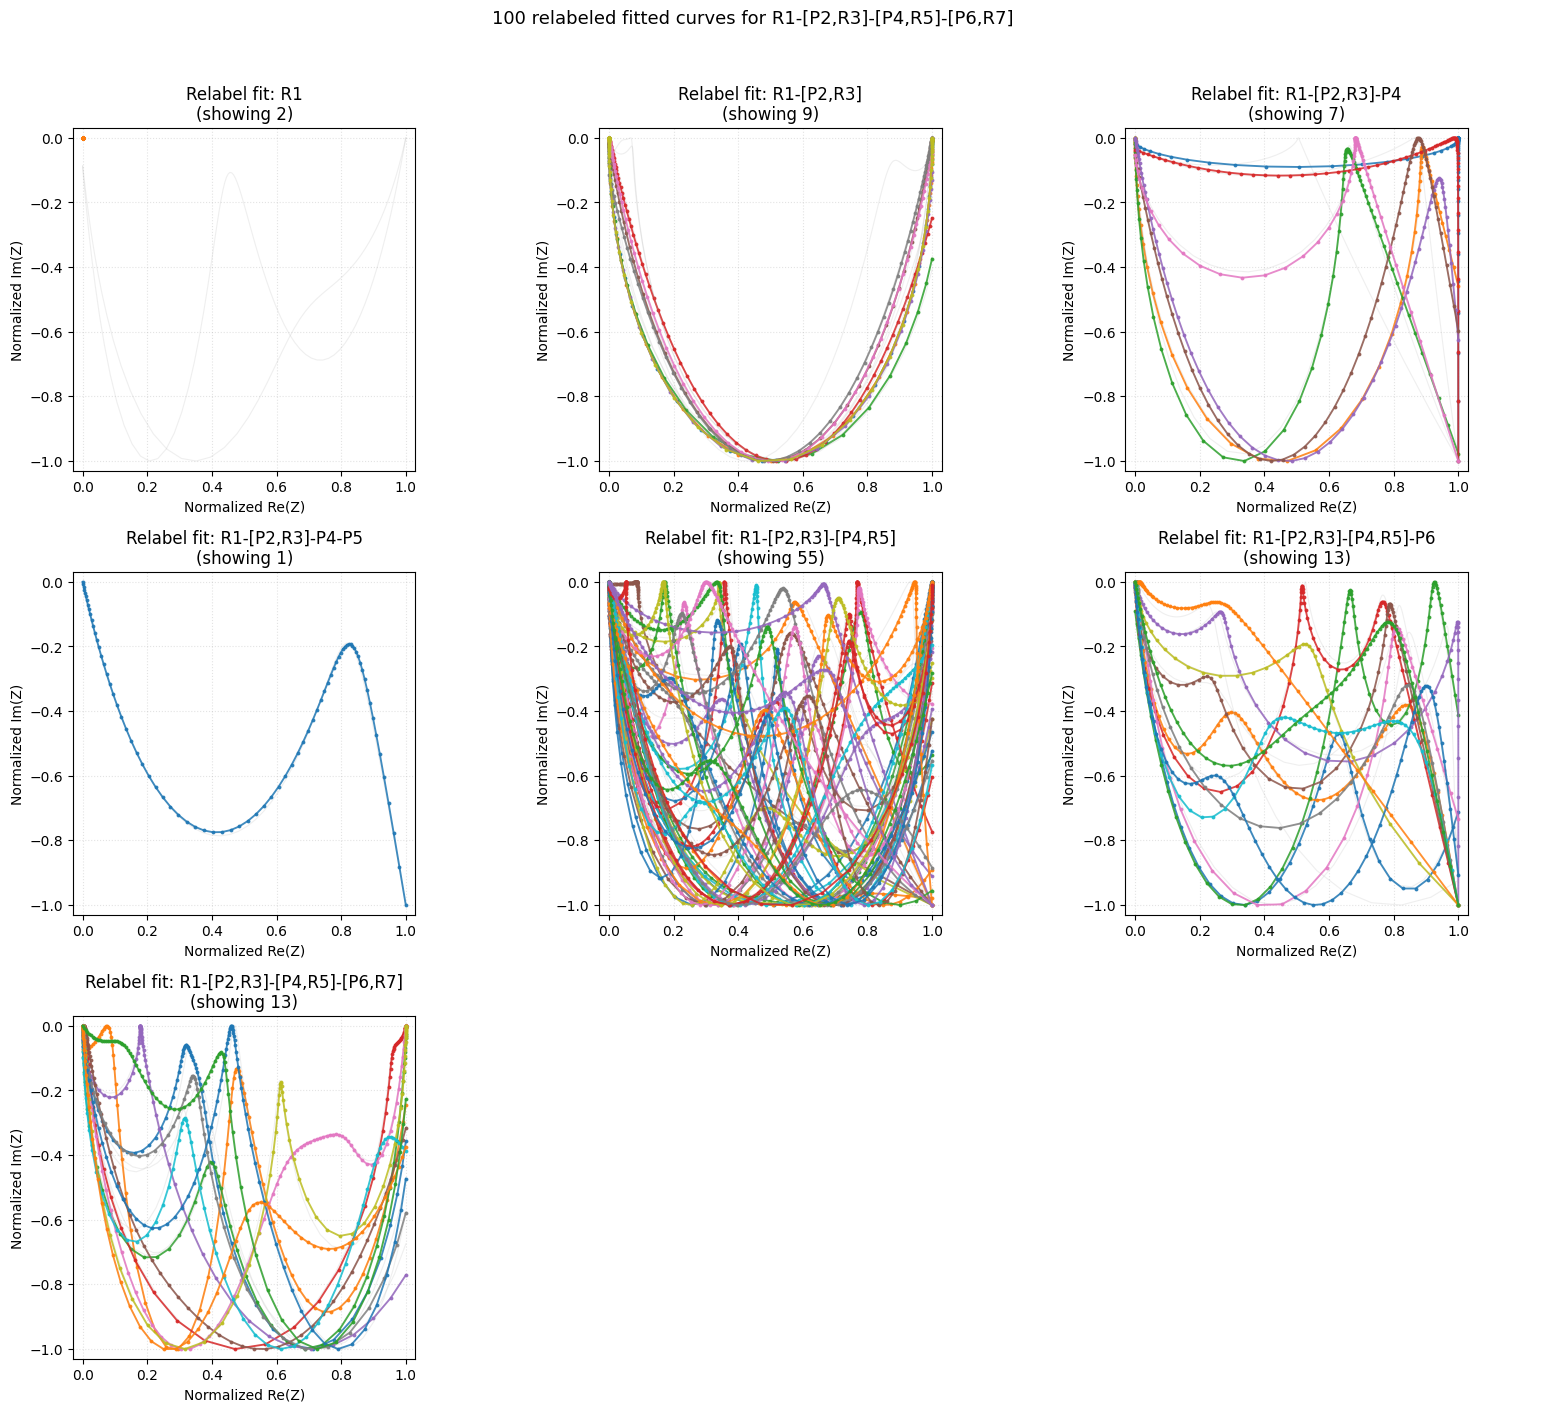

In [41]:
plot_df = random_relabel_results_df.dropna(subset=['relabel_ecm']).copy()
groups = list(plot_df.groupby('relabel_ecm', sort=True))
if not groups:
    raise ValueError('No relabeled ECM groups available to plot.')

show_original_curve_reference = True
n_cols = min(3, len(groups))
n_rows = math.ceil(len(groups) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.4 * n_cols, 4.6 * n_rows), squeeze=False)

for ax, (relabel_ecm, group) in zip(axes.ravel(), groups):
    for _, row in group.iterrows():
        if show_original_curve_reference:
            re_orig, minus_im_orig = row['curve']
            ax.plot(re_orig, -minus_im_orig, linewidth=0.8, alpha=0.18, color='0.65')
        try:
            re_fit, minus_im_fit = simulate_relabel_normalized_curve(row, random_ecm_freq)
            ax.plot(re_fit, -minus_im_fit, linewidth=1.35, alpha=0.85, marker='o', markersize=1.8)
        except Exception as exc:
            ax.text(0.03, 0.95, f'fit plot failed: {exc!r}', transform=ax.transAxes, va='top', fontsize=8)
    ax.set_title(f'Relabel fit: {relabel_ecm}\n(showing {len(group)})')
    ax.set_xlabel('Normalized Re(Z)')
    ax.set_ylabel('Normalized Im(Z)')
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-1.03, 0.03)
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.set_aspect('equal', adjustable='box')

for ax in axes.ravel()[len(groups):]:
    ax.axis('off')

fig.suptitle(f'{len(plot_df)} relabeled fitted curves for {random_ecm_circuit}', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Export Individual Curve Images**

Write one PNG per selected curve with the relabeled ECM in the title, plus a manifest, and package everything into a ZIP file.

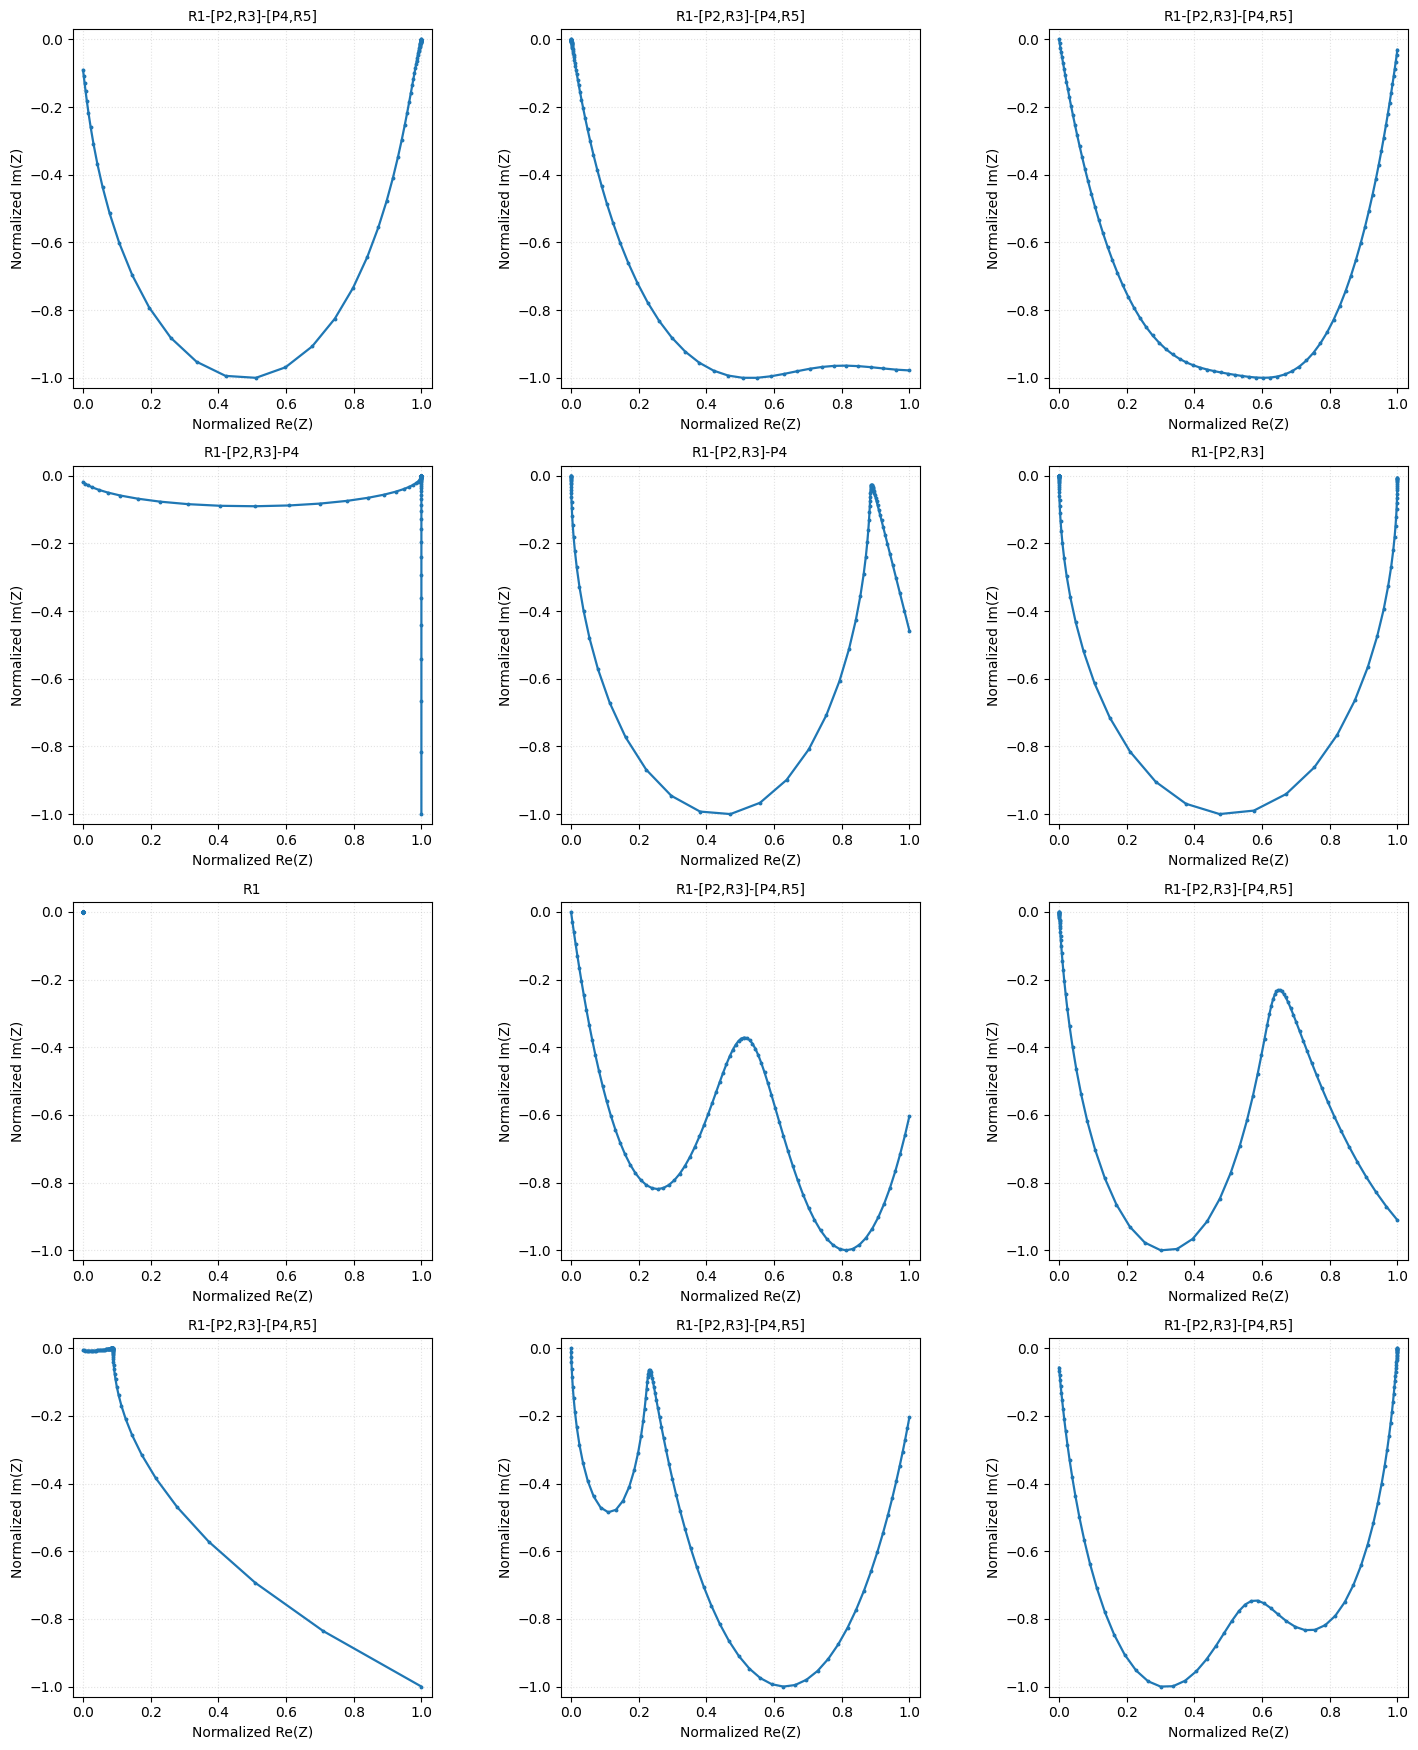

In [34]:
plot_df = random_relabel_results_df.dropna(subset=['relabel_ecm']).sort_values('selected_position').copy()
if plot_df.empty:
    raise ValueError('No relabeled EIS curves are available to plot.')

preview_count = min(12, len(plot_df))
n_cols = min(3, preview_count)
n_rows = math.ceil(preview_count / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 4.4 * n_rows), squeeze=False)

for ax, (_, row) in zip(axes.ravel(), plot_df.head(preview_count).iterrows()):
    re_fit, minus_im_fit = simulate_relabel_normalized_curve(row, random_ecm_freq)
    ax.plot(re_fit, -minus_im_fit, linewidth=1.6, marker='o', markersize=1.8)
    ax.set_title(str(row['relabel_ecm']), fontsize=10, wrap=True)
    ax.set_xlabel('Normalized Re(Z)')
    ax.set_ylabel('Normalized Im(Z)')
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-1.03, 0.03)
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.set_aspect('equal', adjustable='box')

for ax in axes.ravel()[preview_count:]:
    ax.axis('off')

fig.tight_layout()
plt.show()


**Export Curve Metadata CSV**

Write one row per selected curve with original ECM/parameters, final simplified ECM/parameters, the frequency grid, and complex impedance data as JSON columns.

In [ ]:
def json_safe_params(params):
    if not isinstance(params, dict):
        return {}
    safe = {}
    for key, value in params.items():
        try:
            safe[str(key)] = float(value)
        except (TypeError, ValueError):
            safe[str(key)] = str(value)
    return safe


def impedance_json(Z):
    Z = np.asarray(Z)
    return json.dumps({
        'real_ohm': [float(value) for value in np.real(Z)],
        'imag_ohm': [float(value) for value in np.imag(Z)],
    })


def build_curve_metadata_export(df, frequencies=random_ecm_freq):
    sort_cols = [col for col in ('relabel_ecm', 'global_position', 'batch_id', 'selected_position') if col in df.columns]
    export_source = df.dropna(subset=['relabel_ecm']).copy()
    if 'relabel_failed' in export_source.columns:
        export_source = export_source.loc[~export_source['relabel_failed']]
    if sort_cols:
        export_source = export_source.sort_values(sort_cols)

    frequency_json = json.dumps([float(value) for value in frequencies])
    rows = []
    for _, row in export_source.iterrows():
        if len(row['Z']) != len(frequencies):
            raise ValueError('Frequency and impedance data lengths do not match.')
        rows.append({
            'original_ecm': row['original_ecm'],
            'original_params_json': json.dumps(json_safe_params(row['params']), sort_keys=True),
            'final_simplified_ecm': row['relabel_ecm'],
            'final_simplified_params_json': json.dumps(json_safe_params(row['relabel_params']), sort_keys=True),
            'frequency_hz_json': frequency_json,
            'impedance_data_json': impedance_json(row['Z']),
        })
    return pd.DataFrame(rows)




## Balanced Relabel Dataset Generation

Repeat random generation attempts and keep only samples that belong to the target final `relabel_ecm` groups that still need data. A random batch does not guarantee one sample for every target circuit, so the progress printout shows how many samples each batch actually added per target. Final CSV/zip export is handled by the next section.


**Meeting Note: Series Resistor Canonicalization**

With the current balanced relabel workflow, labels are canonicalized before group counting and fixed-count collection. For example:

```text
[P1,R2]-[P3,R4]-R5  ->  R1-[P2,R3]-[P4,R5]-R6
```

The extra `R1` is inserted because the relabeled ECM does not start with a series-connected resistor, then all components are reindexed. The trailing series resistor remains at the end because the current rule only moves standalone `P` elements to the back of the same series level; it does not reorder series resistors.

For the meeting: the order of pure series resistors may be mathematically interchangeable, so moving `R6` to the front and combining/renaming it with the hard-coded leading resistor could also be a valid canonicalization choice. The current implementation keeps the post-FIM series order stable except for standalone `P` elements.


Change the iterations of AutoEIS to lower epochs

After AutoEIS inference, change the C -> P (i.e. C1 -> P1n = 1, and P1w = C1)

R1 should be hard coded toward the simplifed ECM no matter if there is R1 or not if there isn't set R1 - connected and R1 = 0

If there is P (we now should have no C) inside series it should stay at the back

Start 3 groups of [P,R] after 2 groups is working

Combine the functions into a class, let people calling it only using smth like generate_data (params: all non-share params for simplify + FIM, output_dir = "path")
- It will create sub_dir with the name of final relabelled circuit
- We store the csv files inside each sub_dir, for each csv file it store each ECM data(csv file structure: freq, Z_img, Z_real)
- There is a Dataprep inside class AutoREC, reading the files we store inside output_dir, our class should align with the protocal that this Dataprep read

In [47]:
balanced_target_per_relabel = 10
balanced_target_relabel_ecms = None  # None uses the relabel_ecm groups discovered in the first batch.
balanced_min_batches = 1
balanced_max_batches = 200
balanced_seed_start = 1000
random_ensure_ecm_config()

balanced_n_random_candidates = globals().get('n_random_candidates', 5000)
balanced_max_selected_curves = globals().get('max_selected_curves', 100)

def source_ecm_filename_slug(circuit):
    return re.sub(r'[^A-Za-z0-9]+', '_', str(circuit)).strip('_') or 'unknown_ecm'


balanced_source_ecm_slug = source_ecm_filename_slug(random_ecm_circuit)
balanced_output_dir = Path('data')
balanced_output_dir.mkdir(parents=True, exist_ok=True)
balanced_curve_parameter_csv_path = balanced_output_dir / f'balanced_final_params_{balanced_source_ecm_slug}.csv'
balanced_eis_plot_zip_path = balanced_output_dir / f'balanced_eis_plots_{balanced_source_ecm_slug}.zip'

import inspect

required_run_relabel_args = {'params_list', 'Z_list', 'curves', 'batch_seed', 'batch_id'}
missing_run_relabel_args = required_run_relabel_args - set(inspect.signature(run_relabel).parameters)
if missing_run_relabel_args:
    raise RuntimeError(
        'The notebook kernel still has an older run_relabel() definition. '
        'Rerun the **Simplify And Relabel Selected Curves** cell, or restart the kernel and run the notebook from the configuration cell onward.'
    )

def relabel_group_counts(df, target_labels=None):
    source = df.dropna(subset=['relabel_ecm']).copy()
    if 'relabel_failed' in source.columns:
        source = source.loc[~source['relabel_failed']]
    counts = source['relabel_ecm'].value_counts().sort_index()
    if target_labels is not None:
        counts = counts.reindex(target_labels, fill_value=0)
    return counts


def run_selected_relabel_batch(seed, batch_id):
    candidates = random_sample_params(n_candidates=balanced_n_random_candidates, seed=seed)
    params, Z, curves = random_simulate_candidates(candidates)
    filtered_params, filtered_Z, filtered_curves, filter_info = random_filter_high_frequency(params, Z, curves)
    selected_params, selected_Z, selected_curves, selected_idx, selected_scores = random_greedy_select(
        filtered_params, filtered_Z, filtered_curves, k=balanced_max_selected_curves
    )
    batch_df = run_relabel(
        selected_params, selected_Z, selected_curves, batch_seed=seed, batch_id=batch_id
    )
    batch_df = postprocess_relabels(batch_df)
    batch_df['selected_position_in_batch'] = batch_df['selected_position']
    batch_df['selected_filtered_idx'] = selected_idx
    batch_df['selection_score'] = selected_scores

    batch_info = {
        'batch_id': batch_id,
        'seed': seed,
        'valid_candidate_count': len(params),
        'filtered_candidate_count': len(filtered_params),
        'selected_curve_count': len(selected_curves),
        'removed_by_high_frequency_filter': filter_info['removed_candidate_count'],
    }
    return batch_df, batch_info


def take_needed_target_rows(batch_df, counts, target_labels):
    kept = []
    usable = batch_df.dropna(subset=['relabel_ecm']).copy()
    if 'relabel_failed' in usable.columns:
        usable = usable.loc[~usable['relabel_failed']]

    for label in target_labels:
        needed = balanced_target_per_relabel - int(counts.get(label, 0))
        if needed <= 0:
            continue
        label_rows = usable.loc[usable['relabel_ecm'] == label]
        if not label_rows.empty:
            kept.append(label_rows.head(needed))
            counts[label] = int(counts.get(label, 0)) + min(needed, len(label_rows))

    if not kept:
        return batch_df.iloc[0:0].copy(), counts
    return pd.concat(kept, ignore_index=True), counts


def run_balanced_relabel_dataset():
    use_manual_targets = balanced_target_relabel_ecms is not None
    target_labels = sorted(set(balanced_target_relabel_ecms)) if use_manual_targets else None
    kept_batches, batch_infos = [], []
    counts = pd.Series(dtype=int)

    for batch_id in range(balanced_max_batches):
        seed = balanced_seed_start + batch_id
        batch_df, batch_info = run_selected_relabel_batch(seed, batch_id)
        batch_infos.append(batch_info)

        discovered_labels = set(relabel_group_counts(batch_df).index)
        if target_labels is None:
            target_labels = sorted(discovered_labels)
            counts = pd.Series(0, index=target_labels, dtype=int)
        elif counts.empty:
            counts = pd.Series(0, index=target_labels, dtype=int)

        before_counts = counts.copy()
        kept_df, counts = take_needed_target_rows(batch_df, counts, target_labels)
        if not kept_df.empty:
            kept_batches.append(kept_df)

        added_counts = counts.subtract(before_counts, fill_value=0).astype(int)
        under_target = counts[counts < balanced_target_per_relabel]
        target_note = 'manual target' if use_manual_targets else 'first-batch target'
        print(f'Batch {batch_id + 1}: {target_note} groups {len(counts)}, discovered groups {len(discovered_labels)}')
        print('Added this batch:')
        print(added_counts.to_string())
        print('Accumulated target counts:')
        print(counts.to_string())

        if batch_id + 1 >= balanced_min_batches and under_target.empty and len(counts) > 0:
            return pd.concat(kept_batches, ignore_index=True), batch_infos

    raise RuntimeError(
        f'Balanced relabel dataset did not reach {balanced_target_per_relabel} per group '
        f'within {balanced_max_batches} batches. Current counts:\n{counts.to_string()}'
    )


balanced_relabel_results_df, balanced_batch_infos = run_balanced_relabel_dataset()

balanced_generated_counts = relabel_group_counts(balanced_relabel_results_df)
print('Generated relabel counts before final export trimming:')
print(balanced_generated_counts.to_string())
print(f'Generated rows: {len(balanced_relabel_results_df)}')
balanced_generated_counts


Simplify + FIM relabel selected curves: 100%|██████████| 100/100 [00:09<00:00, 10.06it/s]


Batch 1: first-batch target groups 5, discovered groups 5
Added this batch:
R1                     5
R1-P2                  2
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10
Accumulated target counts:
R1                     5
R1-P2                  2
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10


Simplify + FIM relabel selected curves: 100%|██████████| 100/100 [00:10<00:00,  9.81it/s]


Batch 2: first-batch target groups 5, discovered groups 5
Added this batch:
R1                    5
R1-P2                 1
R1-[P2,R3]            0
R1-[P2,R3]-P4         0
R1-[P2,R3]-[P4,R5]    0
Accumulated target counts:
R1                    10
R1-P2                  3
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10


Simplify + FIM relabel selected curves: 100%|██████████| 100/100 [00:09<00:00, 10.97it/s]


...

Simplify + FIM relabel selected curves: 100%|██████████| 100/100 [00:08<00:00, 11.71it/s]


Batch 9: first-batch target groups 5, discovered groups 4
Added this batch:
R1                    0
R1-P2                 0
R1-[P2,R3]            0
R1-[P2,R3]-P4         0
R1-[P2,R3]-[P4,R5]    0
Accumulated target counts:
R1                    10
R1-P2                  9
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10


Simplify + FIM relabel selected curves: 100%|██████████| 100/100 [00:10<00:00,  9.73it/s]

Batch 10: first-batch target groups 5, discovered groups 5
Added this batch:
R1                    0
R1-P2                 1
R1-[P2,R3]            0
R1-[P2,R3]-P4         0
R1-[P2,R3]-[P4,R5]    0
Accumulated target counts:
R1                    10
R1-P2                 10
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10
Generated relabel counts before final export trimming:
relabel_ecm
R1                    10
R1-P2                 10
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10
Generated rows: 50


relabel_ecm
R1                    10
R1-P2                 10
R1-[P2,R3]            10
R1-[P2,R3]-P4         10
R1-[P2,R3]-[P4,R5]    10
Name: count, dtype: int64

**Save Balanced Table Data**

Trim the generated balanced relabel dataframe to the target count per `relabel_ecm`, print counts plus one saved sample per simplified ECM, and save only the table-data zip.


In [48]:
required_balanced_export_vars = [
    'balanced_relabel_results_df', 'balanced_target_per_relabel', 'balanced_target_relabel_ecms',
    'balanced_curve_parameter_csv_path', 'balanced_eis_plot_zip_path',
    'random_ecm_freq', 'relabel_group_counts',
]
missing_balanced_export_vars = [name for name in required_balanced_export_vars if name not in globals()]
if missing_balanced_export_vars:
    raise RuntimeError(
        'Run the **Generate Balanced Relabel Dataset** cell before saving. '
        f'Missing variables: {missing_balanced_export_vars}'
    )

balanced_source_df = balanced_relabel_results_df.dropna(subset=['relabel_ecm']).copy()
balanced_source_df = balanced_source_df.loc[~balanced_source_df['relabel_failed']]
if balanced_target_relabel_ecms is not None:
    balanced_source_df = balanced_source_df.loc[balanced_source_df['relabel_ecm'].isin(balanced_target_relabel_ecms)]

balanced_final_relabel_df = (
    balanced_source_df
    .sort_values(['relabel_ecm', 'batch_id', 'selected_position'])
    .groupby('relabel_ecm', group_keys=False)
    .head(balanced_target_per_relabel)
    .reset_index(drop=True)
)
balanced_final_relabel_df.insert(0, 'global_position', np.arange(len(balanced_final_relabel_df)))

final_counts = relabel_group_counts(balanced_final_relabel_df)
missing = final_counts[final_counts < balanced_target_per_relabel]
if not missing.empty:
    raise RuntimeError(f'Final balanced export still has under-target groups:\n{missing.to_string()}')

frequency_json = json.dumps([float(value) for value in random_ecm_freq])
balanced_curve_parameter_rows = []
for _, row in balanced_final_relabel_df.sort_values(['relabel_ecm', 'global_position']).iterrows():
    original_params = {str(k): float(v) for k, v in row['params'].items()} if isinstance(row['params'], dict) else {}
    relabel_params = {str(k): float(v) for k, v in row['relabel_params'].items()} if isinstance(row['relabel_params'], dict) else {}
    Z = np.asarray(row['Z'])
    balanced_curve_parameter_rows.append({
        'original_ecm': row['original_ecm'],
        'original_params_json': json.dumps(original_params, sort_keys=True),
        'final_simplified_ecm': row['relabel_ecm'],
        'final_simplified_params_json': json.dumps(relabel_params, sort_keys=True),
        'frequency_hz_json': frequency_json,
        'impedance_data_json': json.dumps({
            'real_ohm': [float(value) for value in np.real(Z)],
            'imag_ohm': [float(value) for value in np.imag(Z)],
        }),
    })

balanced_curve_parameter_export_df = pd.DataFrame(balanced_curve_parameter_rows)
balanced_counts_df = (
    final_counts.rename_axis('final_simplified_ecm')
    .reset_index(name='count')
    .sort_values('final_simplified_ecm')
)
balanced_first_sample_df = (
    balanced_curve_parameter_export_df
    .sort_values('final_simplified_ecm')
    .groupby('final_simplified_ecm', group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

balanced_curve_parameter_export_df.to_csv(balanced_curve_parameter_csv_path, index=False)

with zipfile.ZipFile(balanced_eis_plot_zip_path, mode='w', compression=zipfile.ZIP_DEFLATED) as archive:
    for _, row in balanced_final_relabel_df.sort_values(['relabel_ecm', 'global_position']).iterrows():
        Z = np.asarray(simulate_relabel_impedance(row, random_ecm_freq))
        label = str(row['relabel_ecm'])
        safe_label = re.sub(r'[^A-Za-z0-9._-]+', '_', label).strip('_') or 'unknown_ecm'
        fig, ax = plt.subplots(figsize=(5.8, 5.2))
        ax.plot(np.real(Z), -np.imag(Z), linewidth=1.8, color='tab:blue')
        ax.set_title(label, fontsize=10, wrap=True)
        ax.set_xlabel('Re(Z) / ohm')
        ax.set_ylabel('-Im(Z) / ohm')
        ax.grid(True, linestyle=':', alpha=0.35)
        ax.set_aspect('equal', adjustable='datalim')
        fig.tight_layout()
        with BytesIO() as buffer:
            fig.savefig(buffer, format='png', dpi=180, bbox_inches='tight')
            archive.writestr(f"curve_{int(row['global_position']):04d}_{safe_label}.png", buffer.getvalue())
        plt.close(fig)

print('Balanced relabel counts:')
print(balanced_counts_df.to_string(index=False))
print(f'Exported final params CSV: {balanced_curve_parameter_csv_path}')
print(f'Exported EIS plot ZIP: {balanced_eis_plot_zip_path}')
balanced_first_sample_df


Balanced relabel counts:
final_simplified_ecm  count
                  R1     10
               R1-P2     10
          R1-[P2,R3]     10
       R1-[P2,R3]-P4     10
  R1-[P2,R3]-[P4,R5]     10
Exported final params CSV: data/balanced_final_params_R1_P2_R3_P4_R5.csv
Exported EIS plot ZIP: data/balanced_eis_plots_R1_P2_R3_P4_R5.zip


,original_ecm,original_params_json,final_simplified_ecm,final_simplified_params_json,frequency_hz_json,impedance_data_json
0,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.9528414978315972, ""P2w"": 1.077210432...",R1,"{""R1"": 44606.04209706709}","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [44578.05410809433, 44578.3466695..."
1,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.9535102135605631, ""P2w"": 0.007570868...",R1-P2,"{""P2n"": 1.0, ""P2w"": 0.00849882759172107, ""R1"":...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [301488.47776938573, 301490.81675..."
2,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.9846879479203645, ""P2w"": 0.000109079...","R1-[P2,R3]","{""P2n"": 1.0, ""P2w"": 0.00010844207444700859, ""R...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [535808.6115864083, 535808.676121..."
3,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.47523268969317706, ""P2w"": 8.37244545...","R1-[P2,R3]-P4","{""P2n"": 0.4756706293669663, ""P2w"": 8.345175899...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [6417.18763827833, 6432.718604343..."
4,"R1-[P2,R3]-[P4,R5]","{""P2n"": 0.8592694252976275, ""P2w"": 1.925096717...","R1-[P2,R3]-[P4,R5]","{""P2n"": 0.8592694252976275, ""P2w"": 1.925096717...","[100000.0, 81544.07395185171, 66494.3599666504...","{""real_ohm"": [183.49215521135247, 186.42696471..."
